# Classificação de sobrevivência no Titanic: Jev vs Logistic Regression

Neste experimento vamos comparar duas abordagens para prever a sobrevivência
dos passageiros do Titanic:

1. **Logistic Regression**
   - modelo supervisionado;
   - aprende relações estatísticas a partir dos dados de treinamento.

2. **Jev**
   - modelo zero-shot;
   - não será treinado com o dataset;
   - recebe os atributos estruturados de cada passageiro;
   - retorna uma probabilidade através de `Noul`.

A variável alvo é:

- `0`: passageiro não sobreviveu;
- `1`: passageiro sobreviveu.

Os dois métodos serão avaliados sobre exatamente o mesmo conjunto de teste.

Serão analisadas:

- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC
- Matriz de confusão
- Curva ROC
- Curva Precision-Recall
- Distribuição das probabilidades
- Análise de falsos positivos e falsos negativos
- Explicabilidade estruturada das decisões do Jev

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from dotenv import load_dotenv

from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler,
)
from tqdm.auto import tqdm  # Barra de progresso

from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score,
    precision_recall_curve,
    average_precision_score,
)

from typesafe_sdk import (
    TypeSafeClient,
    Noul,
)

/home/leonardo/Documentos/github/jev_laya_studies/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
load_dotenv()

True

In [3]:
THRESHOLD = 0.5

In [4]:
DATA_PATH = "./titanic_train.csv"

df = pd.read_csv(DATA_PATH)

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [6]:
df["Survived"].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

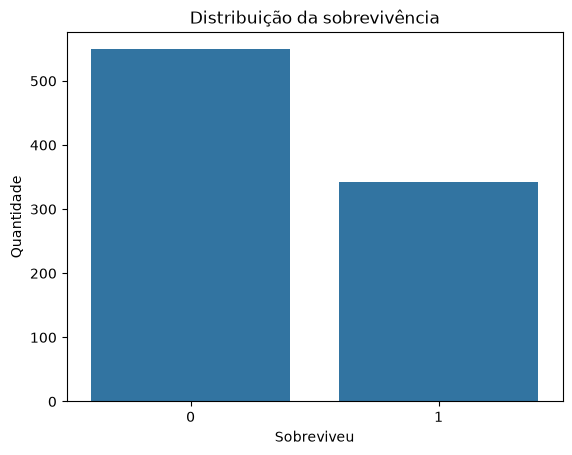

In [7]:
sns.countplot(
    data=df,
    x="Survived",
)

plt.title("Distribuição da sobrevivência")
plt.xlabel("Sobreviveu")
plt.ylabel("Quantidade")

plt.show()

In [8]:
df.isna().sum().sort_values(ascending=False)

Cabin          687
Age            177
Embarked         2
PassengerId      0
Name             0
Pclass           0
Survived         0
Sex              0
Parch            0
SibSp            0
Fare             0
Ticket           0
dtype: int64

## Modelo tradicionar (Regressão logística)

In [9]:
df_model = df.copy()

df_model["HasCabin"] = (
    df_model["Cabin"]
    .notna()
    .astype(int)
)

In [10]:
FEATURES = [
    "Pclass",
    "Sex",
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "Embarked",
    "HasCabin",
]

TARGET = "Survived"

In [11]:
X = df_model[FEATURES]
y = df_model[TARGET]

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y,
)

In [13]:
print("Treinamento:", len(X_train))
print("Teste:", len(X_test))

Treinamento: 712
Teste: 179


In [14]:
numeric_features = [
    "Age",
    "SibSp",
    "Parch",
    "Fare",
]

categorical_features = [
    "Pclass",
    "Sex",
    "Embarked",
    "HasCabin",
]

numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median"),
        ),
        (
            "scaler",
            StandardScaler(),
        ),
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent"),
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
        ),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_pipeline,
            numeric_features,
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_features,
        ),
    ]
)

In [15]:
logistic_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor,
        ),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000
            ),
        ),
    ]
)

In [16]:
logistic_model.fit(
    X_train,
    y_train,
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](8,)","['Pclass','Sex','Age',...,'Fare','Embarked','HasCabin']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,8
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all r

In [17]:
lr_pred = logistic_model.predict(
    X_test
)

lr_score = logistic_model.predict_proba(
    X_test
)[:, 1]

## Usando o Jev

In [18]:
PASSENGER_CLASS = {
    1: "First class",
    2: "Second class",
    3: "Third class",
}

EMBARKATION_PORT = {
    "C": "Cherbourg",
    "Q": "Queenstown",
    "S": "Southampton",
}

In [19]:
def passenger_to_semantic_state(row):
    
    passenger_class = (
        PASSENGER_CLASS.get(row["Pclass"])
        if pd.notna(row["Pclass"])
        else None
    )

    embarkation_port = (
        EMBARKATION_PORT.get(row["Embarked"])
        if pd.notna(row["Embarked"])
        else None
    )

    age = (
        float(row["Age"])
        if pd.notna(row["Age"])
        else None
    )

    fare = (
        float(row["Fare"])
        if pd.notna(row["Fare"])
        else None
    )

    return {
        "passenger_class": passenger_class,

        "sex": (
            row["Sex"]
            if pd.notna(row["Sex"])
            else None
        ),

        "age_in_years": age,

        "number_of_siblings_or_spouses_aboard": (
            int(row["SibSp"])
        ),

        "number_of_parents_or_children_aboard": (
            int(row["Parch"])
        ),

        "passenger_fare": fare,

        "port_of_embarkation": embarkation_port,

        "has_recorded_cabin": bool(
            row["HasCabin"]
        ),
    }

In [20]:
passenger_to_semantic_state(
    X_test.iloc[0]
)

{'passenger_class': 'Third class',
 'sex': 'male',
 'age_in_years': 24.0,
 'number_of_siblings_or_spouses_aboard': 2,
 'number_of_parents_or_children_aboard': 0,
 'passenger_fare': 24.15,
 'port_of_embarkation': 'Southampton',
 'has_recorded_cabin': False}

In [21]:
passenger = passenger_to_semantic_state(
    X_test.iloc[0]
)

with TypeSafeClient() as client:

    response = client.system_one(
        state={
            "passenger": passenger
        },
        questions={
            "survived": Noul(
                instructions=(
                    "Based only on the attributes of `passenger`, "
                    "is this passenger likely to have survived "
                    "the sinking of the Titanic?"
                ),
                criteria={
                    "true": (
                        "The passenger's attributes are consistent "
                        "with circumstances associated with survival."
                    ),
                    "false": (
                        "The passenger's attributes are consistent "
                        "with circumstances associated with not surviving."
                    ),
                },
            )
        },
    )

In [22]:
response.answers["survived"]

NoulAnswer(type='noul', noul=0.18)

### Classificação em lote

In [23]:
def predict_jev_dataset(
    df,
    batch_size=16,
):

    probabilities = []

    with TypeSafeClient() as client:

        for start in tqdm(range(
            0,
            len(df),
            batch_size,
        )):

            end = min(
                start + batch_size,
                len(df),
            )

            batch = df.iloc[start:end]

            batch_probabilities = (
                predict_jev_batch(
                    client,
                    batch,
                )
            )

            probabilities.extend(
                batch_probabilities
            )

            print(
                f"{end}/{len(df)} passageiros classificados"
            )

    return np.array(
        probabilities
    )

In [24]:
def predict_jev_batch(
    client,
    batch,
):

    passengers = [
        passenger_to_semantic_state(row)
        for _, row in batch.iterrows()
    ]

    state = {
        "passengers": passengers
    }

    questions = {
        f"passenger_{i}": Noul(
            instructions=(
                f"Based only on the attributes of `passengers[{i}]`, "
                "is this passenger likely to have survived "
                "the sinking of the Titanic?"
            ),
            criteria={
                "true": (
                    "The passenger's characteristics are consistent "
                    "with circumstances associated with survival."
                ),
                "false": (
                    "The passenger's characteristics are consistent "
                    "with circumstances associated with not surviving."
                ),
            },
        )

        for i in range(len(passengers))
    }

    response = client.system_one(
        state=state,
        questions=questions,
    )

    return [
        response.answers[
            f"passenger_{i}"
        ].noul

        for i in range(len(passengers))
    ]

In [25]:
jev_score = predict_jev_dataset(
    X_test,
    batch_size=16,
)

  8%|▊         | 1/12 [00:00<00:03,  3.21it/s]

16/179 passageiros classificados


 17%|█▋        | 2/12 [00:00<00:02,  3.62it/s]

32/179 passageiros classificados


 25%|██▌       | 3/12 [00:00<00:02,  3.70it/s]

48/179 passageiros classificados


 33%|███▎      | 4/12 [00:01<00:02,  3.50it/s]

64/179 passageiros classificados


 42%|████▏     | 5/12 [00:01<00:01,  3.67it/s]

80/179 passageiros classificados


 50%|█████     | 6/12 [00:01<00:01,  3.76it/s]

96/179 passageiros classificados


 58%|█████▊    | 7/12 [00:01<00:01,  3.81it/s]

112/179 passageiros classificados


 67%|██████▋   | 8/12 [00:02<00:01,  3.85it/s]

128/179 passageiros classificados


 75%|███████▌  | 9/12 [00:02<00:00,  3.82it/s]

144/179 passageiros classificados


 83%|███████▌ | 10/12 [00:02<00:00,  3.88it/s]

160/179 passageiros classificados


 92%|████████▎| 11/12 [00:03<00:00,  3.26it/s]

176/179 passageiros classificados


100%|█████████| 12/12 [00:03<00:00,  3.59it/s]

179/179 passageiros classificados


In [26]:
jev_pred = (
    jev_score >= THRESHOLD
).astype(int)

In [27]:
results = X_test.copy()

results["actual_survival"] = (
    y_test.to_numpy()
)

results["logistic_probability"] = (
    lr_score
)

results["logistic_prediction"] = (
    lr_pred
)

results["jev_probability"] = (
    jev_score
)

results["jev_prediction"] = (
    jev_pred
)

In [28]:
results.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,HasCabin,actual_survival,logistic_probability,logistic_prediction,jev_probability,jev_prediction
565,3,male,24.0,2,0,24.1500,S,0,0,0.066398,0,0.17,0
160,3,male,44.0,0,1,16.1000,S,0,0,0.045245,0,0.25,0
553,3,male,22.0,0,0,7.2250,C,0,1,0.157269,0,0.19,0
860,3,male,41.0,2,0,14.1083,S,0,0,0.035472,0,0.19,0
241,3,female,NaN,1,0,15.5000,Q,0,1,0.671555,1,0.29,0


In [29]:
def calculate_metrics(
    y_true,
    y_pred,
    y_score,
    model_name,
):

    return {
        "Model": model_name,

        "Accuracy": accuracy_score(
            y_true,
            y_pred,
        ),

        "Precision": precision_score(
            y_true,
            y_pred,
        ),

        "Recall": recall_score(
            y_true,
            y_pred,
        ),

        "F1": f1_score(
            y_true,
            y_pred,
        ),

        "ROC-AUC": roc_auc_score(
            y_true,
            y_score,
        ),

        "Average Precision": (
            average_precision_score(
                y_true,
                y_score,
            )
        ),
    }

In [31]:
metrics = pd.DataFrame([
    
    calculate_metrics(
        y_test,
        lr_pred,
        lr_score,
        "Logistic Regression",
    ),

    calculate_metrics(
        y_test,
        jev_pred,
        jev_score,
        "Jev",
    ),
])

metrics

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,Average Precision
0,Logistic Regression,0.810056,0.786885,0.695652,0.738462,0.83834,0.785777
1,Jev,0.709497,0.623188,0.623188,0.623188,0.74664,0.680285


In [33]:
print(
    classification_report(
        y_test,
        lr_pred,
        target_names=[
            "Did not survive",
            "Survived",
        ],
    )
)

                 precision    recall  f1-score   support

Did not survive       0.82      0.88      0.85       110
       Survived       0.79      0.70      0.74        69

       accuracy                           0.81       179
      macro avg       0.80      0.79      0.79       179
   weighted avg       0.81      0.81      0.81       179

                 precision    recall  f1-score   support

Did not survive       0.76      0.76      0.76       110
       Survived       0.62      0.62      0.62        69

       accuracy                           0.71       179
      macro avg       0.69      0.69      0.69       179
   weighted avg       0.71      0.71      0.71       179



In [34]:

print(
    classification_report(
        y_test,
        jev_pred,
        target_names=[
            "Did not survive",
            "Survived",
        ],
    )
)

                 precision    recall  f1-score   support

Did not survive       0.76      0.76      0.76       110
       Survived       0.62      0.62      0.62        69

       accuracy                           0.71       179
      macro avg       0.69      0.69      0.69       179
   weighted avg       0.71      0.71      0.71       179



In [35]:
def plot_confusion_matrix(
    y_true,
    y_pred,
    title,
):

    cm = confusion_matrix(
        y_true,
        y_pred,
    )

    plt.figure(
        figsize=(6, 5)
    )

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cbar=False,
        xticklabels=[
            "Did not survive",
            "Survived",
        ],
        yticklabels=[
            "Did not survive",
            "Survived",
        ],
    )

    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(title)

    plt.show()

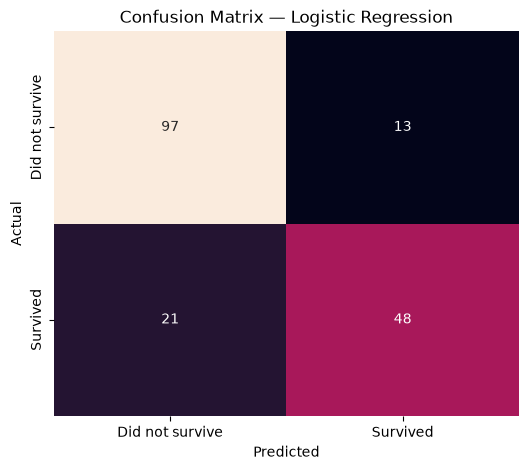

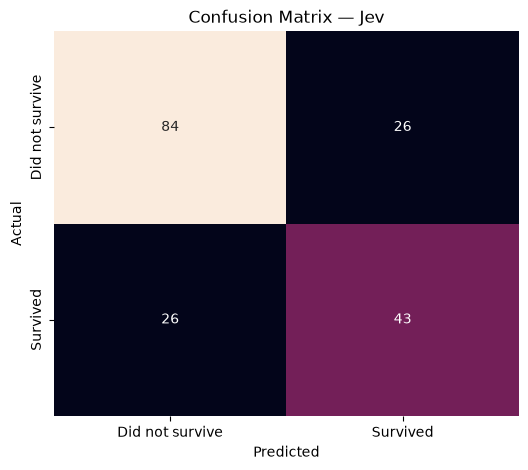

In [37]:
plot_confusion_matrix(
    y_test,
    lr_pred,
    "Confusion Matrix — Logistic Regression",
)

plot_confusion_matrix(
    y_test,
    jev_pred,
    "Confusion Matrix — Jev",
)

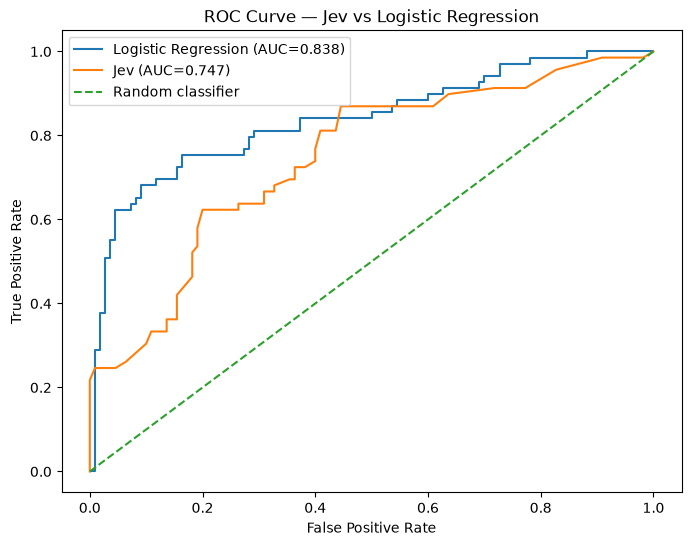

In [41]:
lr_fpr, lr_tpr, _ = roc_curve(
    y_test,
    lr_score,
)

jev_fpr, jev_tpr, _ = roc_curve(
    y_test,
    jev_score,
)

lr_auc = roc_auc_score(
    y_test,
    lr_score,
)

jev_auc = roc_auc_score(
    y_test,
    jev_score,
)

plt.figure(
    figsize=(8, 6)
)

plt.plot(
    lr_fpr,
    lr_tpr,
    label=(
        f"Logistic Regression "
        f"(AUC={lr_auc:.3f})"
    ),
)

plt.plot(
    jev_fpr,
    jev_tpr,
    label=(
        f"Jev "
        f"(AUC={jev_auc:.3f})"
    ),
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random classifier",
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "ROC Curve — Jev vs Logistic Regression"
)

plt.legend()

plt.show()

In [42]:
lr_precision, lr_recall, _ = (
    precision_recall_curve(
        y_test,
        lr_score,
    )
)

jev_precision, jev_recall, _ = (
    precision_recall_curve(
        y_test,
        jev_score,
    )
)

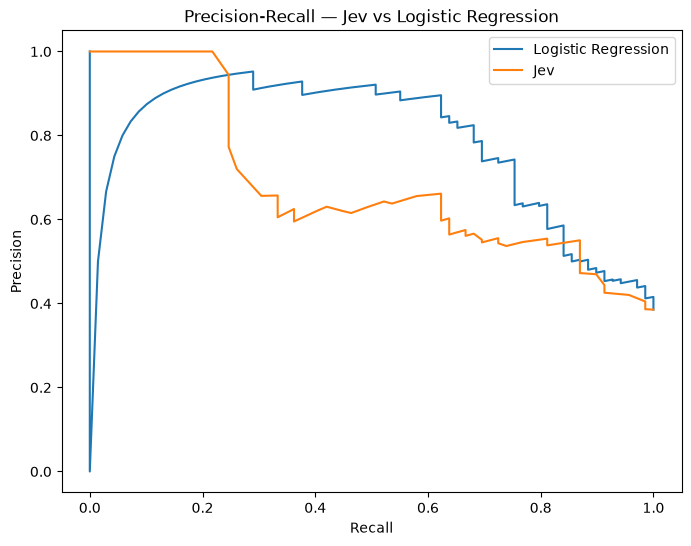

In [43]:
plt.figure(
    figsize=(8, 6)
)

plt.plot(
    lr_recall,
    lr_precision,
    label="Logistic Regression",
)

plt.plot(
    jev_recall,
    jev_precision,
    label="Jev",
)

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title(
    "Precision-Recall — Jev vs Logistic Regression"
)

plt.legend()

plt.show()

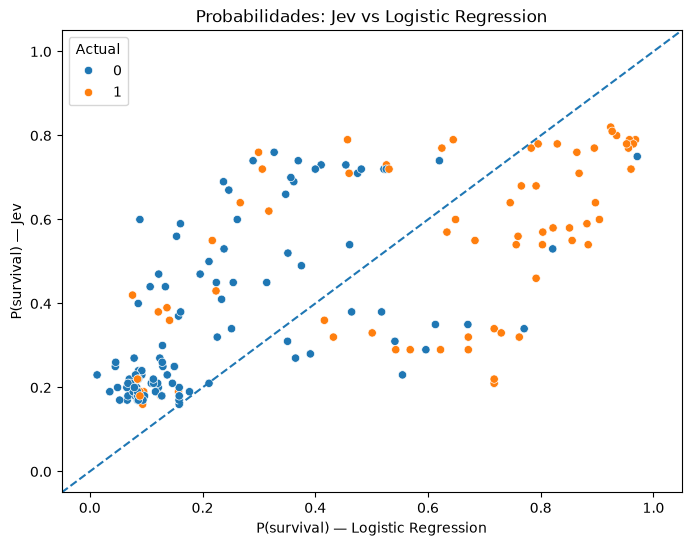

In [45]:
probability_comparison = pd.DataFrame({
    "Logistic Regression": lr_score,
    "Jev": jev_score,
    "Actual": y_test.to_numpy(),
})

plt.figure(
    figsize=(8, 6)
)

sns.scatterplot(
    data=probability_comparison,
    x="Logistic Regression",
    y="Jev",
    hue="Actual",
)

plt.axline(
    (0, 0),
    (1, 1),
    linestyle="--",
)

plt.xlabel(
    "P(survival) — Logistic Regression"
)

plt.ylabel(
    "P(survival) — Jev"
)

plt.title(
    "Probabilidades: Jev vs Logistic Regression"
)

plt.show()

In [47]:
disagreements = results[
    results["logistic_prediction"]
    !=
    results["jev_prediction"]
].copy()

disagreements[
    [
        "Pclass",
        "Sex",
        "Age",
        "Fare",
        "actual_survival",
        "logistic_probability",
        "jev_probability",
        "logistic_prediction",
        "jev_prediction",
    ]
].sort_values(
    "jev_probability",
    ascending=False,
)

,Pclass,Sex,Age,Fare,actual_survival,logistic_probability,jev_probability,logistic_prediction,jev_prediction
690,1,male,31.00,57.0000,1,0.457305,0.79,0,1
92,1,male,46.00,61.1750,0,0.327085,0.76,0,1
587,1,male,60.00,79.2000,1,0.299423,0.76,0,1
536,1,male,45.00,26.5500,0,0.369832,0.74,0,1
492,1,male,55.00,30.5000,0,0.289688,0.74,0,1
671,1,male,31.00,52.0000,0,0.454287,0.73,0,1
698,1,male,49.00,110.8833,0,0.410470,0.73,0,1
712,1,male,48.00,52.0000,1,0.306095,0.72,0,1
336,1,male,29.00,66.6000,0,0.481727,0.72,0,1
137,1,male,37.00,53.1000,0,0.400152,0.72,0,1


## Explicabilidade

In [48]:
def explain_jev_batch(
    client,
    batch,
):

    passengers = [
        passenger_to_semantic_state(row)
        for _, row in batch.iterrows()
    ]

    state = {
        "passengers": passengers
    }

    questions = {}

    for i in range(
        len(passengers)
    ):

        questions[
            f"survival_{i}"
        ] = Noul(
            instructions=(
                f"Based only on `passengers[{i}]`, "
                "are this passenger's characteristics "
                "generally favorable to survival in "
                "the Titanic disaster?"
            )
        )

        questions[
            f"demographic_advantage_{i}"
        ] = Noul(
            instructions=(
                f"Based on the sex and age of "
                f"`passengers[{i}]`, are the passenger's "
                "demographic characteristics favorable "
                "to survival?"
            )
        )

        questions[
            f"class_advantage_{i}"
        ] = Noul(
            instructions=(
                f"Based on the passenger class of "
                f"`passengers[{i}]`, is the passenger's "
                "travel class favorable to survival?"
            )
        )

        questions[
            f"family_advantage_{i}"
        ] = Noul(
            instructions=(
                f"Based on the numbers of siblings, spouses, "
                f"parents and children in `passengers[{i}]`, "
                "does the family situation appear favorable "
                "to survival?"
            )
        )

        questions[
            f"economic_advantage_{i}"
        ] = Noul(
            instructions=(
                f"Based on fare, passenger class and whether "
                f"`passengers[{i}]` has a recorded cabin, "
                "do these attributes suggest circumstances "
                "favorable to survival?"
            )
        )

    response = client.system_one(
        state=state,
        questions=questions,
    )

    rows = []

    for i in range(
        len(passengers)
    ):

        rows.append({
            "survival_factor": (
                response.answers[
                    f"survival_{i}"
                ].noul
            ),

            "demographic_advantage": (
                response.answers[
                    f"demographic_advantage_{i}"
                ].noul
            ),

            "class_advantage": (
                response.answers[
                    f"class_advantage_{i}"
                ].noul
            ),

            "family_advantage": (
                response.answers[
                    f"family_advantage_{i}"
                ].noul
            ),

            "economic_advantage": (
                response.answers[
                    f"economic_advantage_{i}"
                ].noul
            ),
        })

    return rows

In [50]:
error_indices = results[
    results["actual_survival"]
    !=
    results["jev_prediction"]
].index

X_errors = X_test.loc[
    error_indices
]

In [55]:
explanations = []

BATCH_SIZE = 8

with TypeSafeClient() as client:

    for start in range(
        0,
        len(X_errors),
        BATCH_SIZE,
    ):

        batch = X_errors.iloc[
            start:start + BATCH_SIZE
        ]

        explanations.extend(
            explain_jev_batch(
                client,
                batch,
            )
        )

explanation_df = (
    X_errors.copy()
    .reset_index(drop=True)
)      

explanation_values = pd.DataFrame(
    explanations
)

explanation_df = pd.concat(
    [
        explanation_df,
        explanation_values,
    ],
    axis=1,
)

explanation_df

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,HasCabin,survival_factor,demographic_advantage,class_advantage,family_advantage,economic_advantage
0,3,male,22.00,0,0,7.2250,C,0,0.42,0.59,0.10,0.32,0.17
1,3,female,NaN,1,0,15.5000,Q,0,0.26,0.71,0.10,0.46,0.22
2,3,female,36.00,1,0,17.4000,S,0,0.31,0.69,0.13,0.42,0.23
3,1,male,45.00,0,0,26.5500,S,1,0.79,0.78,0.88,0.34,0.82
4,1,male,49.00,1,1,110.8833,C,1,0.83,0.62,0.88,0.57,0.86
5,2,male,34.00,1,0,26.0000,S,0,0.53,0.62,0.60,0.42,0.40
6,3,female,27.00,0,0,7.9250,S,0,0.29,0.75,0.12,0.33,0.18
7,2,male,31.00,1,1,37.0042,C,0,0.56,0.43,0.47,0.54,0.46
8,1,male,19.00,3,2,263.0000,S,1,0.80,0.75,0.88,0.56,0.83
9,3,female,35.00,1,1,20.2500,S,0,0.32,0.73,0.11,0.54,0.31


In [57]:
error_results = results.loc[
    error_indices
].reset_index(drop=True)

explanation_df["actual_survival"] = (
    error_results["actual_survival"]
)

explanation_df["jev_probability"] = (
    error_results["jev_probability"]
)

explanation_df["jev_prediction"] = (
    error_results["jev_prediction"]
)

explanation_df[
    [
        "Sex",
        "Age",
        "Pclass",
        "Fare",
        "actual_survival",
        "jev_probability",
        "demographic_advantage",
        "class_advantage",
        "family_advantage",
        "economic_advantage",
    ]
]

,Sex,Age,Pclass,Fare,actual_survival,jev_probability,demographic_advantage,class_advantage,family_advantage,economic_advantage
0,male,22.00,3,7.2250,1,0.19,0.59,0.10,0.32,0.17
1,female,NaN,3,15.5000,1,0.29,0.71,0.10,0.46,0.22
2,female,36.00,3,17.4000,1,0.32,0.69,0.13,0.42,0.23
3,male,45.00,1,26.5500,0,0.74,0.78,0.88,0.34,0.82
4,male,49.00,1,110.8833,0,0.73,0.62,0.88,0.57,0.86
5,male,34.00,2,26.0000,0,0.59,0.62,0.60,0.42,0.40
6,female,27.00,3,7.9250,1,0.29,0.75,0.12,0.33,0.18
7,male,31.00,2,37.0042,0,0.53,0.43,0.47,0.54,0.46
8,male,19.00,1,263.0000,0,0.72,0.75,0.88,0.56,0.83
9,female,35.00,3,20.2500,1,0.36,0.73,0.11,0.54,0.31


In [58]:
def build_explanation(row):

    positive = []
    negative = []

    if row["demographic_advantage"] >= 0.7:
        positive.append(
            "demographic characteristics"
        )

    elif row["demographic_advantage"] <= 0.3:
        negative.append(
            "demographic characteristics"
        )

    if row["class_advantage"] >= 0.7:
        positive.append(
            "passenger class"
        )

    elif row["class_advantage"] <= 0.3:
        negative.append(
            "passenger class"
        )

    if row["family_advantage"] >= 0.7:
        positive.append(
            "family configuration"
        )

    elif row["family_advantage"] <= 0.3:
        negative.append(
            "family configuration"
        )

    if row["economic_advantage"] >= 0.7:
        positive.append(
            "fare/cabin circumstances"
        )

    elif row["economic_advantage"] <= 0.3:
        negative.append(
            "fare/cabin circumstances"
        )

    explanation = []

    if positive:
        explanation.append(
            "Favorable: "
            + ", ".join(positive)
        )

    if negative:
        explanation.append(
            "Unfavorable: "
            + ", ".join(negative)
        )

    return " | ".join(
        explanation
    )

In [60]:
explanation_df["explanation"] = (
    explanation_df.apply(
        build_explanation,
        axis=1,
    )
)

explanation_df[
    [
        "actual_survival",
        "jev_probability",
        "explanation",
    ]
]

,actual_survival,jev_probability,explanation
0,1,0.19,"Unfavorable: passenger class, fare/cabin circu..."
1,1,0.29,Favorable: demographic characteristics | Unfav...
2,1,0.32,"Unfavorable: passenger class, fare/cabin circu..."
3,0,0.74,"Favorable: demographic characteristics, passen..."
4,0,0.73,"Favorable: passenger class, fare/cabin circums..."
5,0,0.59,
6,1,0.29,Favorable: demographic characteristics | Unfav...
7,0,0.53,
8,0,0.72,"Favorable: demographic characteristics, passen..."
9,1,0.36,Favorable: demographic characteristics | Unfav...


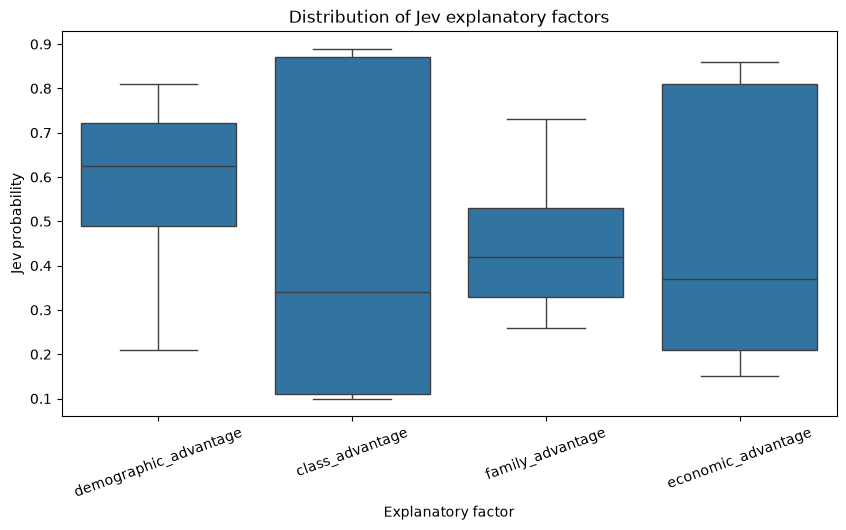

In [62]:
explanation_long = (
    explanation_df[
        [
            "demographic_advantage",
            "class_advantage",
            "family_advantage",
            "economic_advantage",
        ]
    ]
    .melt(
        var_name="factor",
        value_name="probability",
    )
)

plt.figure(
    figsize=(10, 5)
)

sns.boxplot(
    data=explanation_long,
    x="factor",
    y="probability",
)

plt.xticks(
    rotation=20
)

plt.xlabel(
    "Explanatory factor"
)

plt.ylabel(
    "Jev probability"
)

plt.title(
    "Distribution of Jev explanatory factors"
)

plt.show()

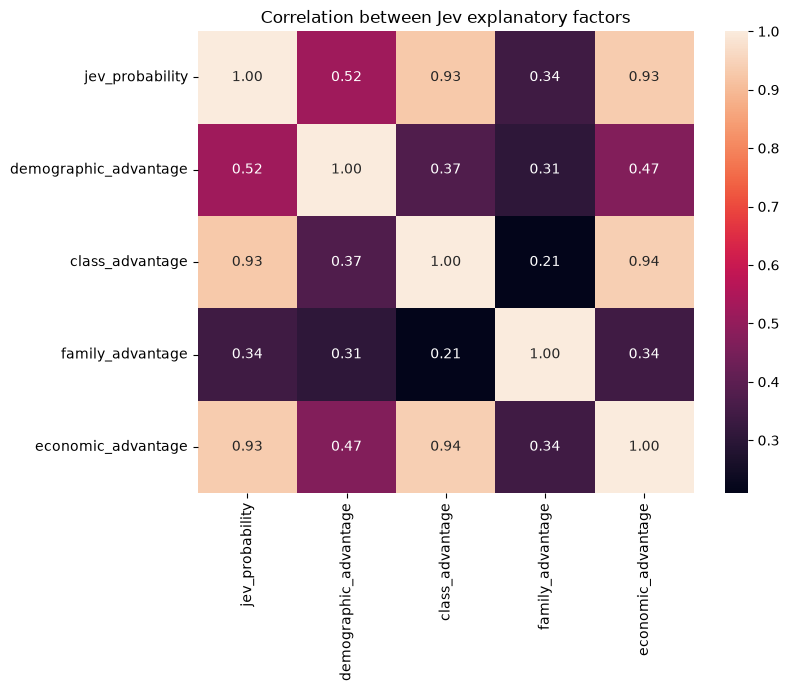

In [65]:
correlation_columns = [
    "jev_probability",
    "demographic_advantage",
    "class_advantage",
    "family_advantage",
    "economic_advantage",
]

correlation = (
    explanation_df[
        correlation_columns
    ]
    .corr()
)

plt.figure(
    figsize=(8, 6)
)

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
)

plt.title(
    "Correlation between Jev explanatory factors"
)

plt.show()